# Aula 04

## Regressão linear e regularização

### Regressão linear simples e múltipla

A regressão linear serve, na maior parte dos casos, para prever algum valor numérico, por exemplo: preço de ações, temperarura, preço de venda de imóvies. A matemática utilizada aqui é a mesma que nós já vimos na escola:

$y=w_{0}+w_{1}x_{1}+w_{2}x_{x} + \dots+w_{n}x_{n}$

- $y$:o que queremos prever.
- $x$: nossas features (dados).
- $w$: os pesos que o modelo aprenderá. Se $w_{1}$ for alto, significa que $x_{1}$ é muito importante.
- $w_{0}$ (bias/viés): onde a reta corta o eixo Y.

**Simples vs Múltupla**:
- **Simples**: Apenas uma variável $x$ (ex: tamanho -> preço). É uma linha em 2D.
- **Múltipla**: Várias variáveis (ex: tamanho + quartos + bairros -> preço). É um hiperplano em n-dimensões.

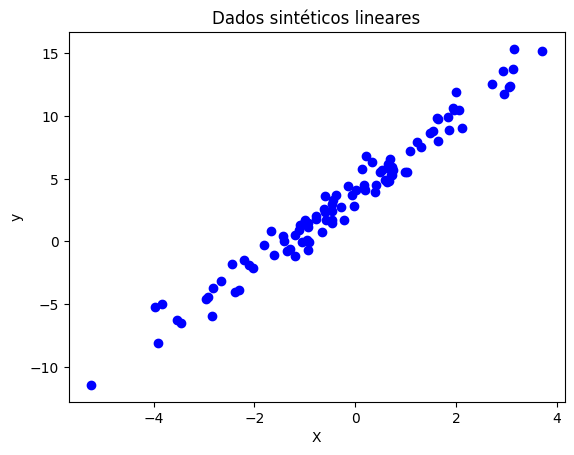

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Gerar os dados (y = 3x + 4 + ruído)
np.random.seed(42)
X = 2 * np.random.randn(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Visualização
plt.scatter(X, y, color='blue')
plt.title('Dados sintéticos lineares')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [2]:
# Treinar o modelo
lin_reg = LinearRegression()
lin_reg.fit(X, y)

print(f'Bias/viés (w0): {lin_reg.intercept_}')  # próximo de 4
print(f'Peso/coeficiente (w1): {lin_reg.coef_}')  # próximo de 3

Bias/viés (w0): [4.00742783]
Peso/coeficiente (w1): [[2.92837142]]


### As métricas de erro. Como sabemos se está bom?

O modelo traçou a reta. Mas ela é boa? Precisamos medir a distância entre o que o modelo previu ($\hat{y}$) e o valor real ($y$).
- R²: O R², ou coeficiente de determinação, mede o quanto a variância dos dados é explicada pelo modelo, variando de 0 a 1 (ou 0% a 100%). Quanto maior o R², melhor o modelo explica os dados. Porém, não podemos confiar somente nessa métrica, devemos ter outras métricas para escolher o melhor modelo.

- EMA: O erro médio absoluto calcula a média da diferença absoluta entre valores reais e previstos, desconsiderando sinais negativos para simplificar a análise. Ele não é influenciado por outliers e utiliza a mesma escala dos dados, facilitando a interpretação. Por exemplo, um EMA de 10 indica que o modelo erra, em média, 10 para mais ou para menos. Esse valor é crucial para decisões futuras, mas é importante também avaliar quanto ele representa percentualmente em relação ao valor real, para ter uma análise mais completa.

- EPAM: O erro percentual absoluto médio mede o percentual de erro em relação aos valores reais. Ele é semelhante ao EMA, mas divide a diferença absoluta entre valor previsto e real pelo valor real, expressando o erro como uma porcentagem. Por exemplo, um EPAM de 25% indica que, em média, as previsões do modelo diferem 25% dos valores reais, seja para mais ou para menos.

- EQM: O erro quadrático médio mede a média das diferenças ao quadrado entre valores previstos e reais, penalizando erros maiores. Quanto maior o EQM, pior o desempenho do modelo. No entanto, como ele eleva as diferenças ao quadrado, a unidade do resultado é distorcida, por exemplo, de metros (m) para metros quadrados (m²), dificultando a interpretação direta. Para resolver isso, utiliza-se a RMSE, uma adaptação que facilita a análise, trazendo o valor de volta à escala original.

- REQM: A raiz do erro quadrático médio é uma métrica que aprimora o EQM ao aplicar a raiz quadrada no cálculo, trazendo o resultado para a mesma escala dos dados originais e facilitando a interpretação. Assim como o EQM, ele penaliza mais severamente diferenças grandes entre os valores previstos e reais, mas é menos influenciado por unidades distorcidas. Apesar de estar na mesma escala, o REQM geralmente apresenta valores maiores que o EMA devido ao impacto de outliers, evidenciando desvios nas previsões. Por exemplo, um REQM de 15 indica que o modelo erra, em média, 15 para mais ou para menos. Essa métrica é ideal para avaliações mais rigorosas do desempenho do modelo.


In [3]:
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             mean_absolute_percentage_error,
                             r2_score)

# Fazer as previsões
y_pred = lin_reg.predict(X)

# Calcular os erros
ema = mean_absolute_error(y, y_pred)
eqm = mean_squared_error(y, y_pred)
reqm = np.sqrt(eqm)
epam = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f'''EMA: {ema:.2f}
EQM: {eqm:.2f}
REQM: {reqm:.2f}
EPAM: {epam:.2f}%
R²: {r2:.2f}''')

EMA: 0.75
EQM: 0.88
REQM: 0.94
EPAM: 18.07%
R²: 0.97


### Overfitting e Underfitting

Agora vamos complicar. E se os dados não formarem uma reta? Vamos criar um dado que faz uma curva.

- **Underfitting (alto viés):** Usar uma reta simples para dados curvos. O modelo é "burro demais".
- **Overfitting (alta variância):** Usar um polinômio grau 100. O modelo liga ponto a ponto, decorando o ruído. Ele funciona bem no treino, mas falha miseravelmente no teste.

Criaremos um cenárion onde temos poucos dados e usamos um polinômio muito complexo

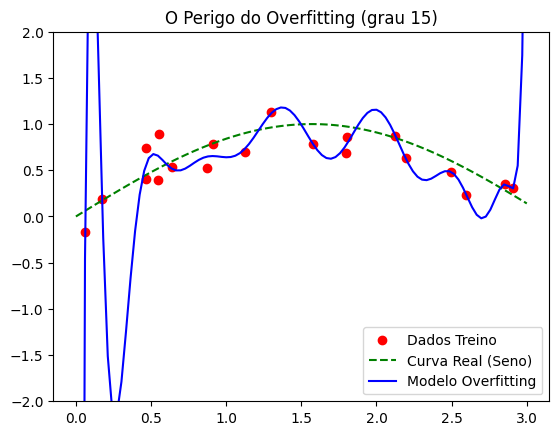

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Gwrar dados não lineares
np.random.seed(42)
m = 20  # poucos dados facilita o overfitting
X = 3 * np.random.rand(m, 1)
y = np.sin(X).ravel() + np.random.randn(m) * 0.2

# X para a plotagem suave da curva
X_plot = np.linspace(0, 3, 100).reshape(-1, 1)

# Criar um modelo complexo de mais (polinômio de grau 15 para 20 dados)
grau = 15
modelo_over = make_pipeline(
    PolynomialFeatures(grau),
    LinearRegression()
)
modelo_over.fit(X, y)

y_plot_over = modelo_over.predict(X_plot)

# Visualizar o desastre
plt.scatter(X, y, color='red', label='Dados Treino')
plt.plot(X_plot, np.sin(X_plot), 'g--', label='Curva Real (Seno)')
plt.plot(X_plot, y_plot_over, color='blue', label='Modelo Overfitting')
plt.ylim(-2, 2)
plt.legend()
plt.title('O Perigo do Overfitting (grau 15)')
plt.show()

Perceba como a linha azul oscila loucamente para tentar passar por todos os pontos vermelhos. Ela não capturou o padrão (curva verde), o modelo decorou o ruído.

### Regularização: Ridge, Lasso e ElasticNet

Como resolvemos o overfitting sem jogar dados fora? Com **regularização**. Nós adicionamos uma "multa" (penalidade) à função de custo do modelo. Nós dizemos ao modelo: "você pode errar um pouco na previsão, contanto que mantenha seus coeficientes $w$ pequenos".
1. **Regressão Ridge (L2)**: Soma o quadrado dos coeficientes na penalidade.
    - Efeito: Reduz todos os pesos, mas não zera nenhum. A curva fica mais suave.
2. **Regressão Lasso (L1):** Soma o valor absoluto dos coeficientes.
    - Efeito: Pode zerar pesos irrelevantes. Funciona como uma seleção de features automática.
3. **ElasticNet**: Uma mistura dos dois.

Vamos aplicar Ridge e Lasso no mesmo problema do polinômio de grau 15 para ver como eles "acalmam" a curva.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.240e-01, tolerance: 1.748e-04
  model = cd_fast.enet_coordinate_descent(


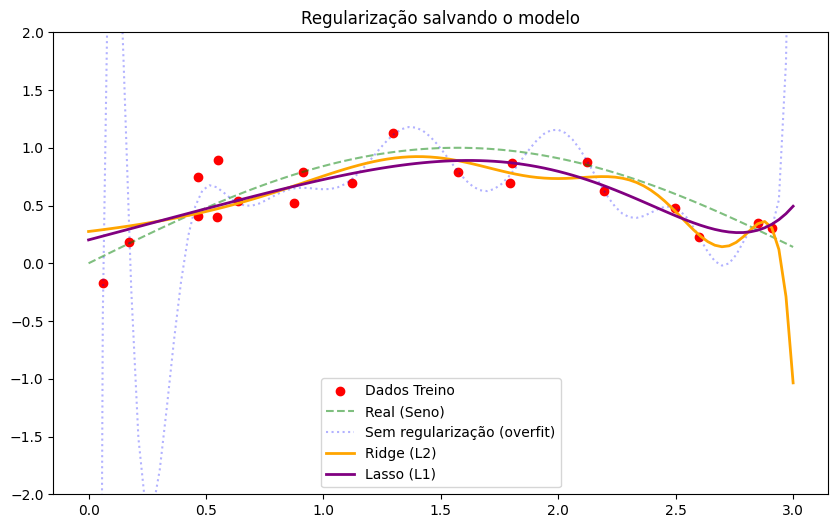

In [12]:
from sklearn.linear_model import Ridge, Lasso

# RIDGE (L2)
# alpha é a força de regularização. Quanto maior,mais simples o modelo fica
reg_ridge = make_pipeline(
    PolynomialFeatures(grau),
    Ridge(alpha=1)
)
reg_ridge.fit(X, y)
y_plot_ridge = reg_ridge.predict(X_plot)

# LASSO (L1)
# Lasso geralemnte precisa de mais iterações para convergir
reg_lasso = make_pipeline(
    PolynomialFeatures(grau),
    Lasso(alpha=0.01, max_iter=10_000)
)
reg_lasso.fit(X, y)
y_plot_lasso = reg_lasso.predict(X_plot)

# Visualização comparativa
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', label='Dados Treino')
plt.plot(X_plot, np.sin(X_plot), 'g--', label='Real (Seno)', alpha=0.5)

# O overfit original
plt.plot(X_plot, y_plot_over, 'b:', label='Sem regularização (overfit)', alpha=0.3)

# As soluções regularizadas
plt.plot(X_plot, y_plot_ridge, 'orange', linewidth=2, label='Ridge (L2)')
plt.plot(X_plot, y_plot_lasso, 'purple', linewidth=2, label='Lasso (L1)')

plt.ylim(-2, 2)
plt.legend()
plt.title('Regularização salvando o modelo')
plt.show()

**Dica:** Sempre comece com Ridge (L2). Lasso (L1) é útil se você acha que tem variáveis inúteis que devem ser zeradas.